In [1]:
import torch
from utils import do_2D_pca, load_image, resize_crop
import torch.nn.functional as F
import matplotlib.pyplot as plt
from vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_MAP,
    FeatureType,
    MODEL_LIST,
)
import numpy as np

/home/ab_aimd_anja_20884/anaconda3/envs/moritz_eng_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def normalize(t_tens):
    return (t_tens - t_tens.min())/(t_tens.max() - t_tens.min())

In [3]:
import torch
import math

def translate_tensor_wrap(x: torch.Tensor, step_x: int = 0, step_y: int = 0) -> torch.Tensor:
    """
    Circularly translate tensor using wrap boundary conditions.

    Args:
        x: Tensor of shape (B, C, H, W)
        step_x: horizontal shift in pixels; positive -> right
        step_y: vertical shift in pixels; positive -> down

    Returns:
        Tensor of same shape (B, C, H, W) translated with wrap (circular) boundary.
    """
    
    if not isinstance(step_x, int) or not isinstance(step_y, int):
        print(type(step_x), type(step_y))
        raise ValueError("translate_tensor_wrap expects integer step_x and step_y for exact circular wrap.")
    # torch.roll uses order: dims (H dim index 2, W dim index 3)
    return torch.roll(x, shifts=(step_y, step_x), dims=(2, 3))


def revert_translation_wrap(feat: torch.Tensor, step_x: int = 0, step_y: int = 0, scale_factor: int = 14,
                            require_exact_division: bool = True) -> torch.Tensor:
    """
    Revert an image-space integer translation on a feature map using circular wrapping.
    The original translation is in *image pixels*; we convert to feature pixels by dividing by scale_factor.

    Args:
        feat: Tensor of shape (B, C, Hf, Wf)  (e.g. (1, 384, H//14, W//14))
        step_x: original image translation (pixels, int)
        step_y: original image translation (pixels, int)
        scale_factor: integer scaling between image and feature map spatial dims (e.g. 14)
        require_exact_division: if True, require that step_x/scale_factor and step_y/scale_factor are integers.
                                If False, the feature shift will be rounded to nearest integer.

    Returns:
        Tensor of same shape (B, C, Hf, Wf) where the translation is reverted using circular wrap.
    """
    if not isinstance(step_x, int) or not isinstance(step_y, int):
        raise ValueError("step_x and step_y must be integers (image pixels).")

    # convert to feature-map pixels (float)
    fx = step_x / float(scale_factor)
    fy = step_y / float(scale_factor)

    # check divisibility if requested
    if require_exact_division:
        if not fx.is_integer() or not fy.is_integer():
            raise ValueError(f"Translation {step_x},{step_y} not divisible by scale_factor={scale_factor}. "
                             "Resulting feature shift would be fractional. "
                             "Set require_exact_division=False to allow rounding.")
        fx = int(fx)
        fy = int(fy)
    else:
        # round to nearest integer feature shift
        fx = int(round(fx))
        fy = int(round(fy))

    # to revert the original translation we roll in the opposite direction
    return torch.roll(feat, shifts=(-fy, -fx), dims=(2, 3))


In [4]:
model = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=False, device="cuda")

In [5]:
img_size = 2*518

In [ ]:
img = load_image("images/black_square_518.png", resize_crop((img_size, img_size),(img_size, img_size)))[0]

In [23]:
def translate_14(img, x_step, y_step, plot:bool=False):
    '''
    step refers to the step in the feature tensor
    '''
    x_step, y_step = x_step*14, y_step*14
    t_tens = translate_tensor_wrap(img.to("cpu"), step_x=x_step, step_y=y_step)

    # inference
    with torch.inference_mode(): 
        pred = model.forward_features(t_tens.to("cuda").float(), make_2D=True).to("cpu")

    un_ten = revert_translation_wrap(pred, step_x=x_step, step_y=y_step, scale_factor=14, require_exact_division=False)#.detach().cpu().squeeze().transpose(2, 0).float()
    
    if plot:
        plt_t_tens= t_tens.clone().detach().cpu().squeeze().transpose(2, 0).float()
        fig, ax = plt.subplots(1, 4, figsize=(15, 5))
        ax[0].imshow(normalize(img.detach().cpu().squeeze().transpose(2, 0).float()))
        ax[0].set_title("orig image")
        ax[1].imshow(normalize(plt_t_tens))
        ax[1].set_title("translated image")
        ax[2].imshow(do_2D_pca(pred.squeeze(), post_norm="minmax"))
        ax[2].set_title("translated_prediction")
        ax[3].imshow(do_2D_pca(un_ten.squeeze(), post_norm="minmax"))
        ax[3].set_title("untranslated prediction image")

    return un_ten

In [34]:
from tqdm import tqdm
x = np.array(range(1, img_size//28))*2
print(x.shape)
y = x.copy()
x_steps, y_steps = np.meshgrid(x, y)
res = torch.zeros((1, 384, img_size//14, img_size//14))

for x, y in tqdm(zip(x_steps.flatten().astype(int), y_steps.flatten().astype(int))):
    #print(res.shape, translate_14(img, x_step=int(x), y_step=int(y)).)
    res += translate_14(img, x_step=int(x), y_step=int(y)).cpu()
mean_res = res/x_steps.flatten().shape[0]

(36,)


1296it [02:05, 10.31it/s]


In [39]:
import tifffile 
tifffile.imwrite("default_img_trans_mean.tiff", mean_res.numpy())

In [40]:
torch.save(mean_res, "default_img_trans_mean.pt")

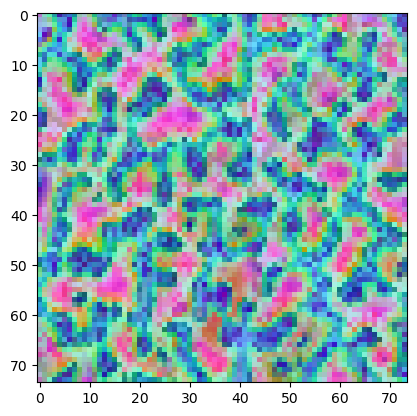

In [35]:
plt.imshow(do_2D_pca(mean_res.squeeze(), post_norm="minmax"))

In [ ]:
x_steps = 

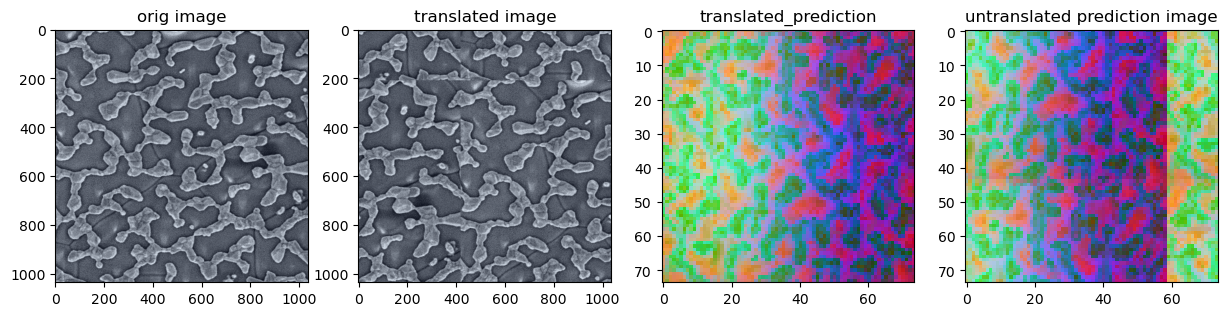

In [30]:
un_trans_feats = translate_14(img, x_step=15, y_step=30, plot=True)

In [ ]:
un_trans_feats.shape

torch.Size([1, 384, 74, 74])